# 课堂演示：图上随机游走的块 I/O 优化（45 分钟）

《计算机系统设计》（研究生一年级）· 教师演示脚本

| 时间 | 环节 | 对应论文 |
|---|---|---|
| 0–5' | §1 二阶偏置游走的转移概率 | node2vec |
| 5–15' | §2 一阶游走：逐块迭代 vs state-aware 加载 | GraphWalker |
| 15–25' | §3 二阶游走：naive 饥饿 vs AUW 调度 | SOWalker |
| 25–35' | §4 分区优化：切边最少 ≠ 加载最少 | 三篇综合 |
| 35–40' | §5 互动四问 | — |
| 40–45' | §6 作业布置 | — |

> 运行方式：在 `lab-rw-io/` 目录下启动 Jupyter，逐 cell 执行并配合讲解。

## §0 环境与图数据（课前预跑）

karate 俱乐部图：34 点 / 78 边，天然双社区。baseline 按顶点编号顺序等分 4 块（[9,9,8,8]），跨块边 47/78（60%）。

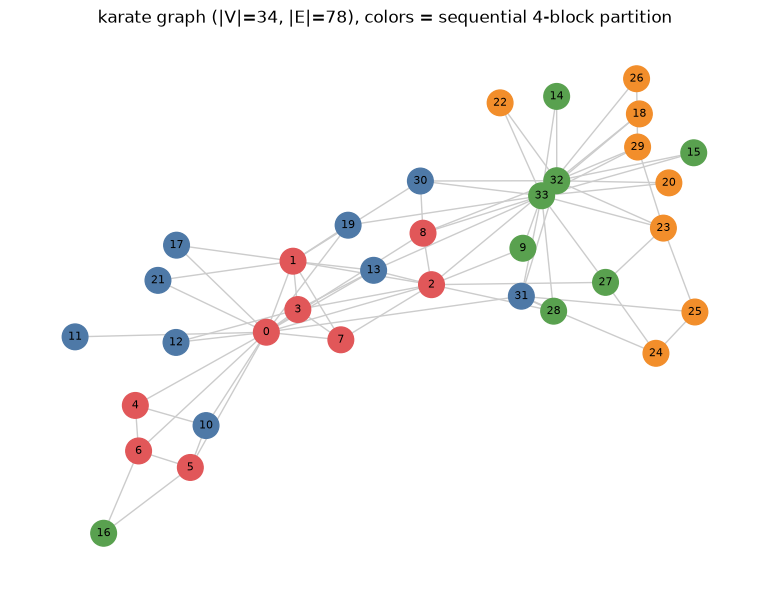

In [1]:
import json, os
import networkx as nx
import matplotlib.pyplot as plt
from walk_sim import run_sim

DATA = 'data'
G = nx.read_edgelist(os.path.join(DATA, 'karate.edgelist'), nodetype=int)

def load_meta(path):
    m = {}
    for line in open(path):
        v, b = map(int, line.split())
        m[v] = b
    return m

meta0 = load_meta(os.path.join(DATA, 'meta.txt'))
colors = ['#e15759', '#4e79a7', '#59a14f', '#f28e2b']
pos = nx.spring_layout(G, seed=7)
plt.figure(figsize=(7.5, 5.5))
nx.draw(G, pos, node_color=[colors[meta0[v]] for v in sorted(G.nodes())],
        with_labels=True, node_size=340, font_size=8, edge_color='#cccccc')
plt.title('karate graph (|V|=34, |E|=78), colors = sequential 4-block partition')
plt.show()

def brief(s):
    keys = ('converged', 'rounds', 'total_loads', 'walk_updating_rate', 'io_utilization')
    return json.dumps({k: s[k] for k in keys}, ensure_ascii=False)

## §1 node2vec：二阶偏置游走（0–5 分钟）

**讲解要点**：一阶游走下一步只依赖当前点 v；node2vec 的转移概率还依赖上一步节点 t：

$$P(x\,|\,t,v) \propto w_{vx}\cdot\alpha_{pq}(t,x),\quad \alpha=\begin{cases}1/p & d(t,x)=0\\ 1 & d(t,x)=1\\ 1/q & d(t,x)=2\end{cases}$$

- p 控制**回跳**倾向，q 控制**向外探索**（BFS↔DFS 插值）。
- **关键问题抛给学生**：计算 d(t,x) 需要谁的邻居表？→ t 的邻接结构必须在手边。这埋下 §3 的伏笔。

In [2]:
# 黑板手算的代码版：固定 t=0, v=1，枚举候选下一跳 x∈N(1)，取 p=0.5, q=2.0
t, v, p, q = 0, 1, 0.5, 2.0
nt = set(G.neighbors(t))
rows = []
for x in sorted(G.neighbors(v)):
    d = 0 if x == t else (1 if x in nt else 2)
    w = {0: 1/p, 1: 1.0, 2: 1/q}[d]
    rows.append((x, d, w))
Z = sum(r[2] for r in rows)
print(f't={t}, v={v}, p={p}, q={q}')
for x, d, w in rows:
    print(f'  x={x:2d}  d(t,x)={d}  weight={w:5.2f}  P={w/Z:.3f}')

t=0, v=1, p=0.5, q=2.0
  x= 0  d(t,x)=0  weight= 2.00  P=0.211
  x= 2  d(t,x)=1  weight= 1.00  P=0.105
  x= 3  d(t,x)=1  weight= 1.00  P=0.105
  x= 7  d(t,x)=1  weight= 1.00  P=0.105
  x=13  d(t,x)=1  weight= 1.00  P=0.105
  x=17  d(t,x)=1  weight= 1.00  P=0.105
  x=19  d(t,x)=1  weight= 1.00  P=0.105
  x=21  d(t,x)=1  weight= 1.00  P=0.105
  x=30  d(t,x)=2  weight= 0.50  P=0.053


## §2 GraphWalker：state-aware I/O（5–15 分钟）

**讲解要点**：
- 外存模型：图分 4 块放"磁盘"，内存最多驻留 M=2 块；任务 = 每点 10 次、步长 20 的游走（340 walkers / 6800 步）。
- **iteration-based**（逐块迭代，Pregel/GraphChi 式）：不管块里有没有 walker，按固定顺序换入换出 → 大量 I/O 浪费（论文 §1 Limitation 1）。
- **state-aware**（GraphWalker §3）：优先加载含 walker 最多的块；walk-conscious 换出（淘汰含 walker 最少的块，而非 LRU）。

**现场对比**：roundrobin（逐块迭代稻草人）vs stateaware。

roundrobin   {"converged": true, "rounds": 40, "total_loads": 80, "walk_updating_rate": 0.5, "io_utilization": 0.05}
stateaware   {"converged": true, "rounds": 40, "total_loads": 52, "walk_updating_rate": 0.5, "io_utilization": 0.0758}


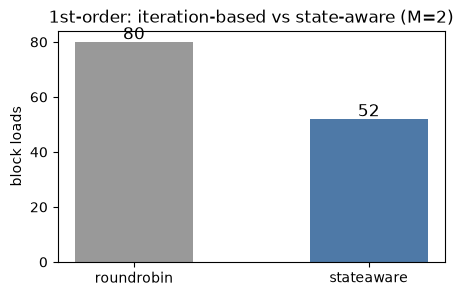

In [3]:
res1 = {}
for pol in ['roundrobin', 'stateaware']:
    s, _, _ = run_sim(DATA, order=1, policy=pol)
    res1[pol] = s
    print(f'{pol:12s}', brief(s))

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(res1.keys(), [s['total_loads'] for s in res1.values()],
       color=['#999999', '#4e79a7'], width=0.5)
for i, s in enumerate(res1.values()):
    ax.text(i, s['total_loads'] + 1, str(s['total_loads']), ha='center', fontsize=12)
ax.set_ylabel('block loads')
ax.set_title('1st-order: iteration-based vs state-aware (M=2)')
plt.show()

# 提问①：为什么有的块只有 1 个 walker 也会被加载？（提示：M=2 的名额竞争与平局规则）

## §3 SOWalker：二阶游走的 I/O 灾难与解救（15–25 分钟）

**讲解要点**：
- 二阶可推进 ⟺ **prev 块与 curr 块同时驻留**（否则算不出 d(t,x)）→ 一阶式调度产生大量 **non-updatable walks** 与"无用 walk I/O"（SOWalker §2：node2vec 的块 I/O 可达 DeepWalk 的 6 倍）。
- **walk matrix**：W(i,j) = 处于 (prev块=i, curr块=j) 的 walker 数；调度目标 = 选 M 块使块内可更新游走数 **AUW** 最大（benefit-aware，对应论文 MWS 的课堂简化版）。

**现场对比**：naive（一阶调度直接套用）→ **不收敛**；auw → 收敛。注意 naive 的 total_loads 反而"很低"——这是饥饿假象，必须看 walk_updating_rate！

naive: {"converged": false, "rounds": 20001, "total_loads": 42, "walk_updating_rate": 0.0004, "io_utilization": 0.096}  <- 42 次"低加载"但游走停滞（更新率 0.0004）
auw  : {"converged": true, "rounds": 87, "total_loads": 101, "walk_updating_rate": 0.2299, "io_utilization": 0.0408}  <- 真正完成 6800 步


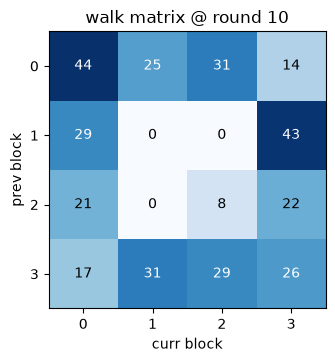

In [4]:
s_nv, _, _ = run_sim(DATA, order=2, policy='naive')
s_aw, _, _ = run_sim(DATA, order=2, policy='auw', record_wm=True)
print('naive:', brief(s_nv), ' <- 42 次"低加载"但游走停滞（更新率 0.0004）')
print('auw  :', brief(s_aw), ' <- 真正完成 6800 步')

# walk matrix 热图：第 10 轮快照（行=prev块，列=curr块，值=walker 数）
snap = s_aw['wm_history'][9]
W = snap['W']
fig, ax = plt.subplots(figsize=(4.2, 3.6))
ax.imshow(W, cmap='Blues')
ax.set_xticks(range(4)); ax.set_yticks(range(4))
ax.set_xlabel('curr block'); ax.set_ylabel('prev block')
ax.set_title(f"walk matrix @ round {snap['round']}")
for r in range(4):
    for c in range(4):
        ax.text(c, r, W[r][c], ha='center', va='center',
                color='white' if W[r][c] > max(map(max, W)) / 2 else 'black')
plt.show()

# 提问②：二阶为何比一阶多这么多加载？（提示：双块共驻约束下，M=2 的名额几乎被一对 (prev,curr) 占满）

## §4 分区优化：切边最少 ≠ 加载最少（25–35 分钟）

**讲解要点**：直觉上"社区内边密、跨块边少"的分区应该最优——但实验会给出反转：

- KL 递归二分把跨块边从 47 压到 31，一阶加载却从 52 **升到** 72；
- 面向加载次数直接做局部搜索的分区（ref_meta）跨块边高达 55，一阶加载却只有 42。

**结论**：优化目标必须锚定 *walker 局部性*（块内可连续推进的步数），而非静态切边数。二阶还要进一步考虑 (prev,curr) 块对的共驻频率（AUW 结构）。

**课堂提问③**：若把 M 从 2 调到 4（全图驻留），加载次数会降到多少？→ 恰好 4（冷启动），但 updating_rate 到 1.0；追问：真实系统为什么不能这么做？

In [5]:
parts = {'sequential(baseline)': 'meta.txt',
         'KL-balanced       ': 'community_meta.txt',
         'local-search(ref) ': 'ref_meta.txt'}
print(f"{'partition':<22}{'crossE':>7}{'1st':>6}{'2ndAUW':>8}")
for name, mp in parts.items():
    m = load_meta(os.path.join(DATA, mp))
    cross = sum(1 for u, v in G.edges() if m[u] != m[v])
    s1, _, _ = run_sim(DATA, order=1, meta=os.path.join(DATA, mp))
    s2, _, _ = run_sim(DATA, order=2, policy='auw', meta=os.path.join(DATA, mp))
    print(f'{name:<22}{cross:>7}{s1["total_loads"]:>6}{s2["total_loads"]:>8}')

partition              crossE   1st  2ndAUW
sequential(baseline)       47    52     101


KL-balanced                31    72      84
local-search(ref)          55    42     133


## §5 互动四问（35–40 分钟）

1. 二阶游走为什么必须 prev 块也在内存？d(t,x) 的三种取值分别对应什么图结构？
2. M=2→4 时加载次数为何不等于 0？（冷启动下界 = 块数）
3. 社区分区 vs 顺序分区谁更优？为什么"看切边数"会误判？
4. 我们的**同步轮次**框架与 GraphWalker 的**异步 re-entry**（块内连走多步直到撞边界）有何本质差异？各自的工程取舍是什么？

## §6 作业布置（40–45 分钟）

- **阶段一（一阶，1 周）**：复现 baseline（52 次）；提交自定义分区 `mypart.txt`（恰好 4 块、每块 4–17 点），L≤47 得 +20，L≤42 得 +40。
- **阶段二（二阶，1 周）**：解释 naive 为何不收敛；自定义调度函数和/或分区联合优化，L≤86 得 +15，L≤71 得 +30。
- 报告必须同时给出 total_loads / walk_updating_rate / io_utilization 三指标并讨论权衡。
- 加分项（+10）：极端 p/q 实验；8 块/M=2 重跑；ER 对照图。

详见 `README.md` 与 `student_lab.ipynb`。